**1. Imports**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import itertools
import seaborn as sns
import time
import pandas as pd

**2. Dataset Loader**

In [2]:
class EyeBoundingBoxDataset(Dataset):
    def __init__(self, subject_ids, root_dir, transform=None):
        self.root_dir = root_dir
        self.subject_ids = subject_ids
        self.transform = transform
        self.data = []

        for subject_id in self.subject_ids:
            subject_dir = os.path.join(root_dir, 'openEDS', 'openEDS', subject_id)
            bbox_file = os.path.join(root_dir, 'bbox', 'bbox', f"{subject_id}.txt")
            with open(bbox_file, 'r') as f:
                bboxes = [list(map(float, line.strip().split())) for line in f.readlines()]
            for i in range(len(bboxes) - 1):
                img0_path = os.path.join(subject_dir, f"{i}.png")
                img1_path = os.path.join(subject_dir, f"{i+1}.png")
                self.data.append((img0_path, img1_path, bboxes[i+1]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img0_path, img1_path, bbox = self.data[idx]
        img0 = Image.open(img0_path).convert('L')
        img1 = Image.open(img1_path).convert('L')

        if self.transform:
            img0 = self.transform(img0)
            img1 = self.transform(img1)

        diff = img1 - img0
        input_tensor = torch.cat((img1, diff), dim=0)
        target = torch.tensor(bbox, dtype=torch.float32)
        return input_tensor, target

**3. Model Definition**

In [3]:
class LightweightBBoxCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.features(x)
        if hasattr(self, 'fc1'):
            x = F.relu(self.fc1(x), inplace=False)
            x = self.fc2(x)
        else:
            x = self.regressor(x)
        return x

**4. Data Splitting**

In [4]:
def split_subjects_and_save(root_dir, output_file='subject_split.txt', seed=42):
    random.seed(seed)
    subject_path = os.path.join(root_dir, 'openEDS', 'openEDS')
    all_subjects = sorted([d for d in os.listdir(subject_path) if d.startswith('S_') and os.path.isdir(os.path.join(subject_path, d))])

    random.shuffle(all_subjects)
    n_total = len(all_subjects)
    n_train = int(0.7 * n_total)
    n_val = int(0.2 * n_total)

    train_subjects = all_subjects[:n_train]
    val_subjects = all_subjects[n_train:n_train + n_val]
    test_subjects = all_subjects[n_train + n_val:]

    with open(output_file, 'w') as f:
        f.write("Training Subjects:\n")
        for s in train_subjects:
            f.write(f"{s}\n")
        f.write("\nValidation Subjects:\n")
        for s in val_subjects:
            f.write(f"{s}\n")
        f.write("\nTest Subjects:\n")
        for s in test_subjects:
            f.write(f"{s}\n")

    print(f"Subject split saved to {output_file}")
    return train_subjects, val_subjects, test_subjects


**5. Model Training with Movement Threshold**

In [5]:
def train_model_by_subject(root_dir, train_subjects, val_subjects, model=None, num_epochs=20, batch_size=16, lr=1e-3):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])

    train_dataset = EyeBoundingBoxDataset(train_subjects, root_dir, transform)
    val_dataset = EyeBoundingBoxDataset(val_subjects, root_dir, transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    device = next(model.parameters()).device if model else torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if model is None:
        model = LightweightBBoxCNN().to(device)
    else:
        model.to(device)

    torch.autograd.set_detect_anomaly(True)

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)

            # SAFE: use outputs for loss, don't clamp here
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, targets).item() * inputs.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        # if (epoch + 1) % 5 == 0:
        #     torch.save(model.state_dict(), f'checkpoints/cp_e{epoch + 1}')
        #     print('Checkpoint saved...')

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    return model, train_losses, val_losses

**6. Plotting**

In [6]:
def plot_training_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

**7. Evaluation Metric: mIoU**

In [7]:
def calculate_mIoU(pred_boxes, true_boxes):
    ious = []
    for pred, true in zip(pred_boxes, true_boxes):
        xA = max(pred[0], true[0])
        yA = max(pred[2], true[2])
        xB = min(pred[1], true[1])
        yB = min(pred[3], true[3])

        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (pred[1] - pred[0]) * (pred[3] - pred[2])
        boxBArea = (true[1] - true[0]) * (true[3] - true[2])
        unionArea = boxAArea + boxBArea - interArea

        iou = interArea / unionArea if unionArea > 0 else 0
        ious.append(iou)

    return np.mean(ious)

**8. Sensitivity Analysis**

In [8]:
def sensitivity_analysis(root_dir, val_subjects):
    from tqdm import tqdm
    thresholds = [0.005, 0.01, 0.02, 0.05, 0.1]
    lrs = [5e-2, 1e-2, 5e-3, 1e-3]
    batch_sizes = [4, 8, 16]
    hidden_sizes = [32, 64, 128]

    results = {}
    times = {}

    all_combinations = list(itertools.product(thresholds, lrs, batch_sizes, hidden_sizes))
    outer_bar = tqdm(all_combinations, desc='Sensitivity Analysis', leave=True)

    for t, lr, bs, hs in outer_bar:
        outer_bar.set_description(f"t={t}, lr={lr}, bs={bs}, hs={hs}")

        class ModifiedCNN(LightweightBBoxCNN):
            def __init__(self):
                super().__init__()
                self.regressor = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(64 * 8 * 8, hs),
                    nn.ReLU(inplace=False),
                    nn.Linear(hs, 4)
                )

        model = ModifiedCNN().to('cuda' if torch.cuda.is_available() else 'cpu')

        with tqdm(total=2, desc="Train/Eval", leave=False) as inner_bar:
            model, _, _ = train_model_by_subject(
                root_dir, val_subjects, val_subjects,
                model=model, num_epochs=5, batch_size=bs, lr=lr
            )
            inner_bar.update(1)

            # Evaluation
            transform = transforms.Compose([
                transforms.Resize((64, 64)),
                transforms.ToTensor()
            ])
            val_dataset = EyeBoundingBoxDataset(val_subjects, root_dir, transform)
            val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

            model.eval()
            preds_all, trues_all = [], []
            total_time = 0.0
            n_batches = 0

            with torch.no_grad():
                for inputs, targets in val_loader:
                    start_time = time.time()
                    inputs = inputs.to(next(model.parameters()).device)
                    outputs = model(inputs).cpu()
                    end_time = time.time()

                    # SAFE clamping after model output
                    outputs_clamped = outputs.clone()
                    outputs_clamped[:, 0] = outputs_clamped[:, 0].clamp(0, 639)
                    outputs_clamped[:, 1] = outputs_clamped[:, 1].clamp(0, 639)
                    outputs_clamped[:, 2] = outputs_clamped[:, 2].clamp(0, 399)
                    outputs_clamped[:, 3] = outputs_clamped[:, 3].clamp(0, 399)

                    total_time += (end_time - start_time)
                    n_batches += 1

                    preds_all.extend(outputs_clamped.numpy())
                    trues_all.extend(targets.numpy())

            inner_bar.update(1)

        miou = calculate_mIoU(preds_all, trues_all)
        avg_time = total_time / n_batches if n_batches > 0 else 0

        key = (t, lr, bs, hs)
        results[key] = miou
        times[key] = avg_time

    return results, times

**9. Visualizaiton**

In [9]:
def plot_sensitivity_heatmap(results, param1='threshold', param2='lr', metric_name='mIoU'):
    x_vals = sorted(set(k[0] for k in results.keys()))
    y_vals = sorted(set(k[1] for k in results.keys()))

    heatmap_data = np.zeros((len(y_vals), len(x_vals)))
    for (t, lr, _, _), score in results.items():
        i = y_vals.index(lr)
        j = x_vals.index(t)
        heatmap_data[i, j] = score

    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, xticklabels=x_vals, yticklabels=y_vals, cmap='viridis')
    plt.xlabel(param1)
    plt.ylabel(param2)
    plt.title(f'{metric_name} Heatmap')
    plt.show()


In [10]:
# Run Sensitivity Analysis
root_dir = r"C:\Users\omarh\OneDrive - Georgia Institute of Technology\openEDS2019"
_, val_subjects, _ = split_subjects_and_save(root_dir)
# results, times = sensitivity_analysis(root_dir, val_subjects)

# # Plot results
# plot_sensitivity_heatmap(times, param1='threshold', param2='lr', metric_name='Prediction Time (s)')

Subject split saved to subject_split.txt


**10. Export to CSV**

In [11]:
def export_results_to_csv(results, times, filename='sensitivity_results.csv'):
    rows = []
    for key in results:
        threshold, lr, batch_size, hidden_size = key
        miou = results[key]
        time_per_batch = times.get(key, None)
        rows.append({
            'threshold': threshold,
            'learning_rate': lr,
            'batch_size': batch_size,
            'hidden_size': hidden_size,
            'mIoU': miou,
            'avg_prediction_time': time_per_batch
        })

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"Results exported to {filename}")

In [12]:
results, times = sensitivity_analysis(root_dir, val_subjects)
export_results_to_csv(results, times)

t=0.005, lr=0.05, bs=4, hs=32:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 1/5 - Train Loss: 37.5022 - Val Loss: 24.7922
Epoch 2/5 - Train Loss: 22.6591 - Val Loss: 17.9534
Epoch 3/5 - Train Loss: 20.4348 - Val Loss: 16.5901
Epoch 4/5 - Train Loss: 21.6046 - Val Loss: 33.3860


Epoch 5/5 - Train Loss: 32.5895 - Val Loss: 32.7287


t=0.005, lr=0.05, bs=4, hs=64:   1%|          | 1/180 [05:36<16:43:23, 336.33s/it]

Epoch 1/5 - Train Loss: 40.5214 - Val Loss: 33.8317
Epoch 2/5 - Train Loss: 33.3624 - Val Loss: 30.9720
Epoch 3/5 - Train Loss: 33.2105 - Val Loss: 30.7570
Epoch 4/5 - Train Loss: 33.1621 - Val Loss: 31.9283


...

t=0.1, lr=0.001, bs=16, hs=128:  99%|█████████▉| 179/180 [15:00:17<04:47, 287.35s/it]

Epoch 1/5 - Train Loss: 47.9358 - Val Loss: 28.0951
Epoch 2/5 - Train Loss: 25.5606 - Val Loss: 25.0761
Epoch 3/5 - Train Loss: 22.7347 - Val Loss: 20.6365
Epoch 4/5 - Train Loss: 21.8751 - Val Loss: 20.0100


Epoch 5/5 - Train Loss: 20.3605 - Val Loss: 19.0185


t=0.1, lr=0.001, bs=16, hs=128: 100%|██████████| 180/180 [15:04:57<00:00, 301.65s/it]

Results exported to sensitivity_results.csv


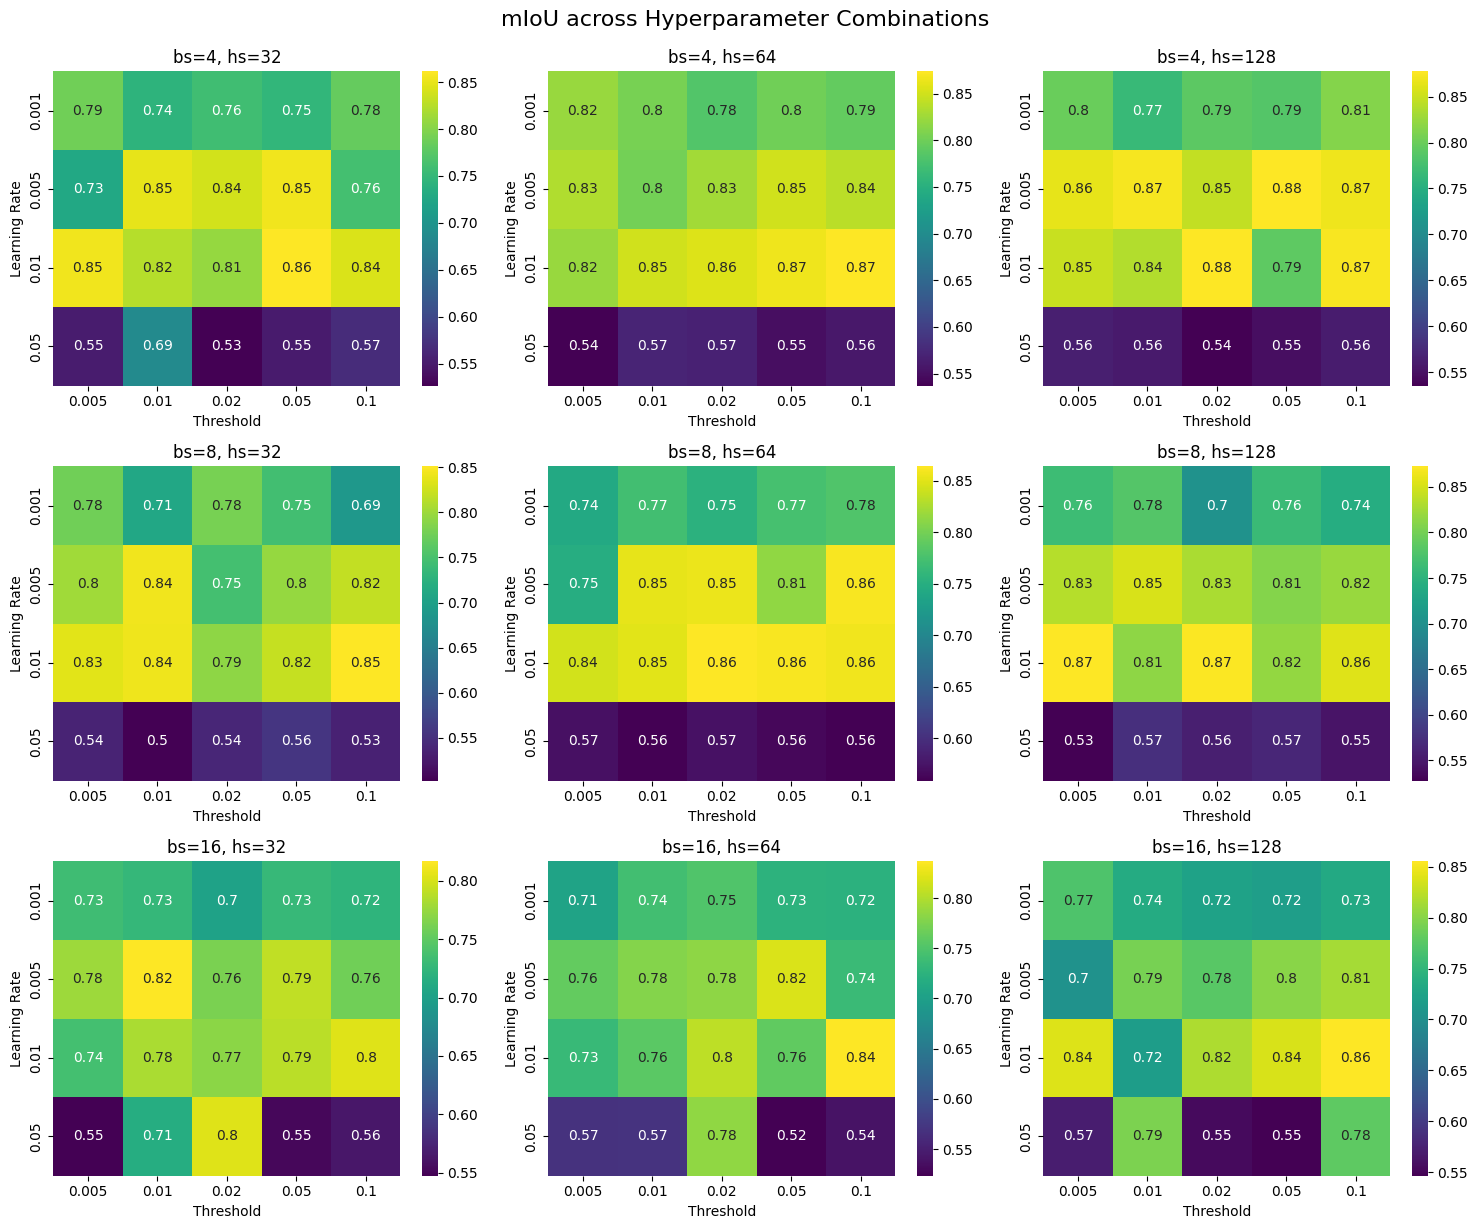

In [13]:
df = pd.read_csv('sensitivity_results.csv')

# Unique values
batch_sizes = sorted(df['batch_size'].unique())
hidden_sizes = sorted(df['hidden_size'].unique())

# Create subplot grid
fig, axes = plt.subplots(len(batch_sizes), len(hidden_sizes), figsize=(5 * len(hidden_sizes), 4 * len(batch_sizes)))

for i, bs in enumerate(batch_sizes):
    for j, hs in enumerate(hidden_sizes):
        ax = axes[i][j] if len(batch_sizes) > 1 else axes[j]

        # Subset data for this (bs, hs)
        subset = df[(df['batch_size'] == bs) & (df['hidden_size'] == hs)]

        # Pivot for heatmap: x=threshold, y=lr
        pivot = subset.pivot_table(index='learning_rate', columns='threshold', values='mIoU')

        sns.heatmap(pivot, annot=True, cmap='viridis', ax=ax)
        ax.set_title(f'bs={bs}, hs={hs}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Learning Rate')

plt.tight_layout()
plt.suptitle('mIoU across Hyperparameter Combinations', fontsize=16, y=1.02)
plt.show()

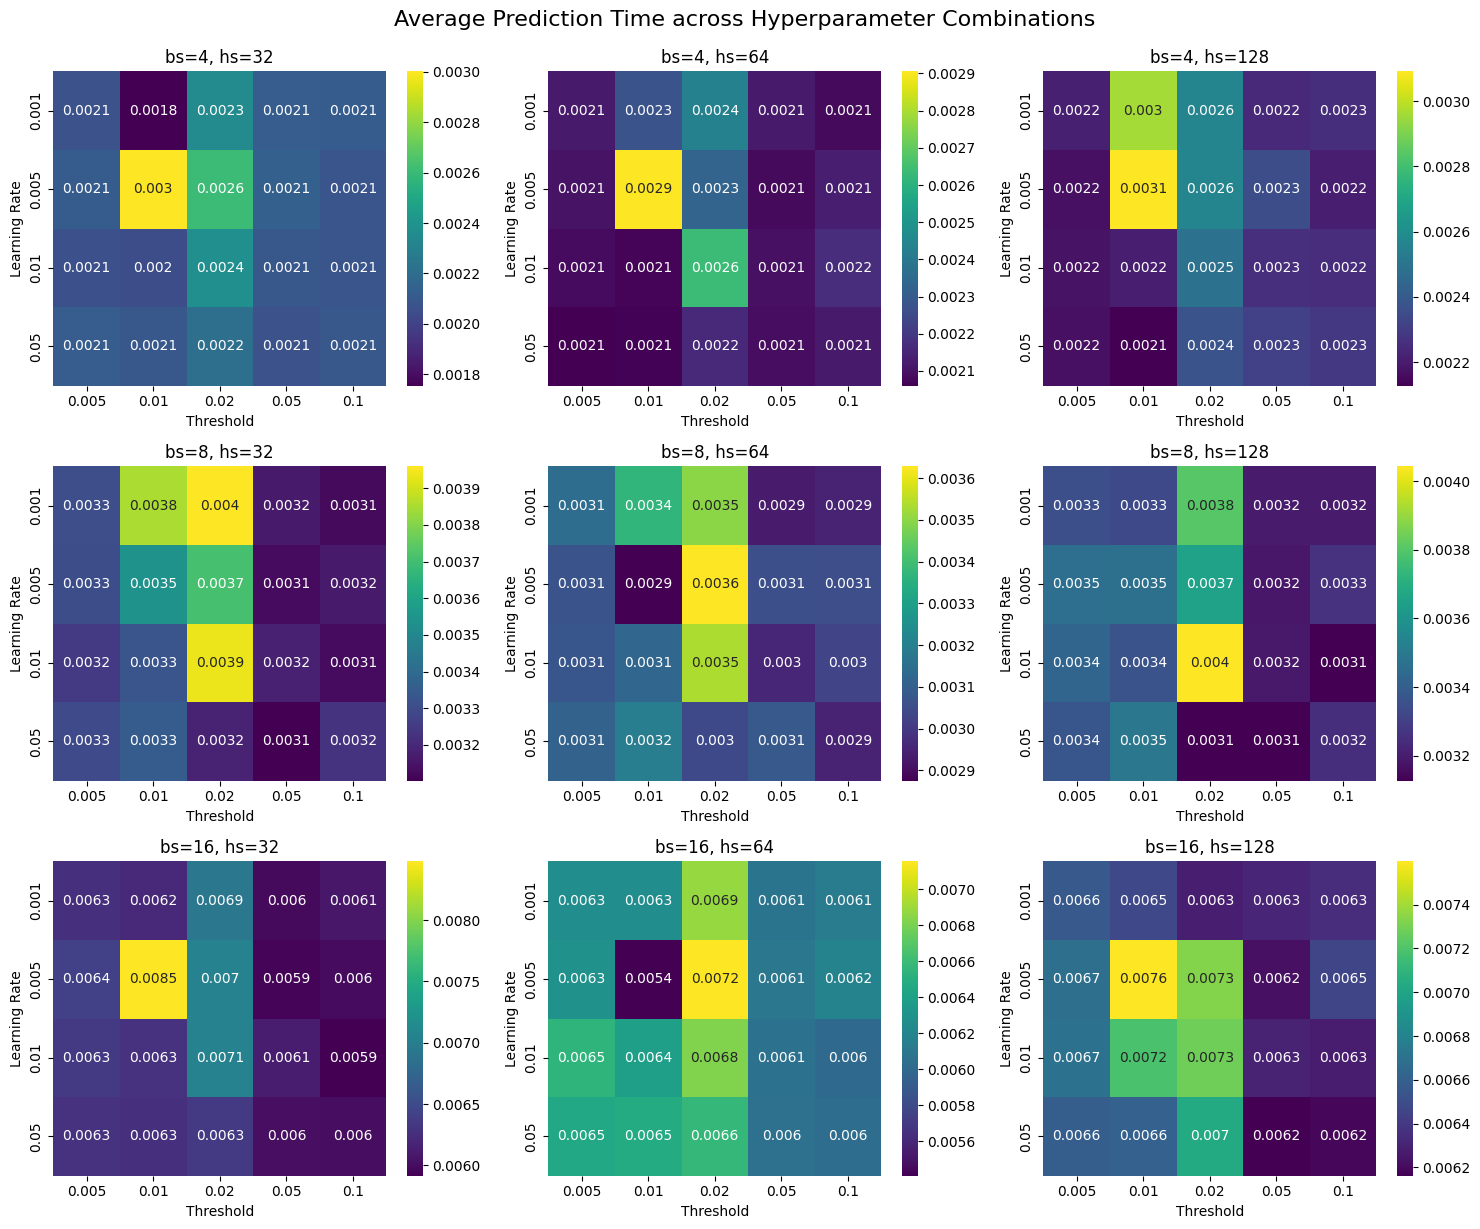

In [14]:
df = pd.read_csv('sensitivity_results.csv')

# Unique values
batch_sizes = sorted(df['batch_size'].unique())
hidden_sizes = sorted(df['hidden_size'].unique())

# Create subplot grid
fig, axes = plt.subplots(len(batch_sizes), len(hidden_sizes), figsize=(5 * len(hidden_sizes), 4 * len(batch_sizes)))

for i, bs in enumerate(batch_sizes):
    for j, hs in enumerate(hidden_sizes):
        ax = axes[i][j] if len(batch_sizes) > 1 else axes[j]

        # Subset data for this (bs, hs)
        subset = df[(df['batch_size'] == bs) & (df['hidden_size'] == hs)]

        # Pivot for heatmap: x=threshold, y=lr
        pivot = subset.pivot_table(index='learning_rate', columns='threshold', values='avg_prediction_time')

        sns.heatmap(pivot, annot=True, cmap='viridis', ax=ax)
        ax.set_title(f'bs={bs}, hs={hs}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Learning Rate')

plt.tight_layout()
plt.suptitle('Average Prediction Time across Hyperparameter Combinations', fontsize=16, y=1.02)
plt.show()